# Speech Emotion Recognition using the RAVDESS AND TESS dataset

For this task, I have used 5252 samples from

the Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) dataset
the Toronto emotional speech set (TESS) dataset
The samples include:

**1440 **speech files and **1012** Song files from **RAVDESS**. This dataset includes recordings of 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech includes calm, happy, sad, angry, fearful, surprise, and disgust expressions, and song contains calm, happy, sad, angry, and fearful emotions. Each file was rated 10 times on emotional validity, intensity, and genuineness. Ratings were provided by 247 individuals who were characteristic of untrained adult research participants from North America. A further set of 72 participants provided test-retest data. High levels of emotional validity, interrater reliability, and test-retest intrarater reliability were reported. Validation data is open-access, and can be downloaded along with our paper from PLoS ONE.

**2800** files from **TESS**. A set of 200 target words were spoken in the carrier phrase "Say the word _____' by two actresses (aged 26 and 64 years) and recordings were made of the set portraying each of seven emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). There are 2800 stimuli in total. Two actresses were recruited from the Toronto area. Both actresses speak English as their first language, are university educated, and have musical training. Audiometric testing indicated that both actresses have thresholds within the normal range.

Mounting Drive so that we can access the contents directly from the drive

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Importing Librosa library(A python package) for extracting important features of the audio like the pitch,tone.

In [2]:
!pip install librosa --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


Loading one audio file from the drive using librosa.
Librosa loads the audio file as a floating point time series.

In [1]:
import os
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disable all GPUs
print("Available devices:")
print(tf.config.list_physical_devices())

2025-05-03 11:32:02.549307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746253922.562202   30504 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746253922.566435   30504 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-03 11:32:02.580664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-05-03 11:32:04.177817: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-05-03 11:32:04.177842: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: hcl-12
2025-05-03 11:32:04.177847: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: hcl-12
2025-05-03 11:32:04.177937: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 550.163.1
2025-05-03 11:32:04.177953: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 550.163.1
2025-05-03 11:32:04.177957: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 550.163.1


In [2]:
import librosa
from librosa import display

import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

data, sampling_rate = librosa.load(path+'/Actor_01/03-01-01-01-01-01-01.wav')

Path to dataset files: /home/ali/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


Plotting the audio file which was just loaded by librosa using waveplot function of librosa.This Function Plots the amplitude envelope of a waveform.

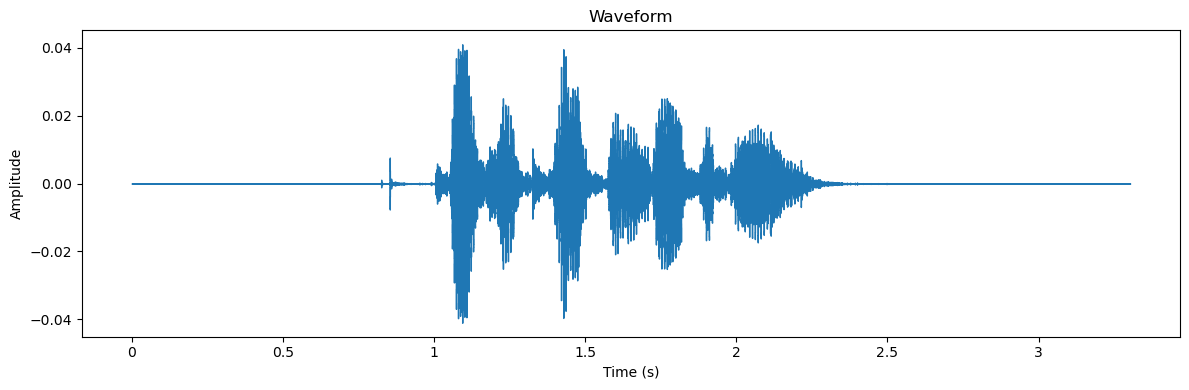

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Assuming you already have `data` and `sampling_rate`
plt.figure(figsize=(12, 4))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


# Load all files

We will create our numpy array extracting Mel-frequency cepstral coefficients (MFCCs), while the classes to predict will be extracted from the name of the file (see the introductory section of this notebook to see the naming convention of the files of this dataset).

In [4]:
import time
import os
import numpy as np
# path = '/content/drive/My Drive/Ravtess/'
lst = []

start_time = time.time()

for subdir, dirs, files in os.walk(path):
  for file in files:
      try:
        #Load librosa array, obtain mfcss, store the file and the mcss information in a new array
        X, sample_rate = librosa.load(os.path.join(subdir,file), res_type='kaiser_fast')
        mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T,axis=0) 
        # The instruction below converts the labels (from 1 to 8) to a series from 0 to 7
        # This is because our predictor needs to start from 0 otherwise it will try to predict also 0.
        file = int(file[7:8]) - 1 
        arr = mfccs, file
        lst.append(arr)
      # If the file is not valid, skip it
      except ValueError:
        continue

print("--- Data loaded. Loading time: %s seconds ---" % (time.time() - start_time))

--- Data loaded. Loading time: 99.14706206321716 seconds ---


In [5]:
# Creating X and y: zip makes a list of all the first elements, and a list of all the second elements.
X, y = zip(*lst)

In [6]:
import numpy as np
X = np.asarray(X)
y = np.asarray(y)


X.shape, y.shape

((2880, 40), (2880,))

In [7]:
# Saving joblib files to not load them again with the loop above

import joblib

X_name = 'X.joblib'
y_name = 'y.joblib'
save_dir = '../dataset_features/new'

savedX = joblib.dump(X, os.path.join(save_dir, X_name))
savedy = joblib.dump(y, os.path.join(save_dir, y_name))

In [8]:
# Loading saved models
import joblib
X = joblib.load(save_dir+'/X.joblib')
y = joblib.load(save_dir+'/y.joblib')

# Decision Tree Classifier

To make a first attempt in accomplishing this classification task I chose a decision tree:

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dtree = DecisionTreeClassifier()

In [12]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
predictions = dtree.predict(X_test)

In [14]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.56      0.67      0.61        61
           1       0.92      0.78      0.85       147
           2       0.75      0.80      0.77       132
           3       0.83      0.82      0.83       134
           4       0.85      0.87      0.86       120
           5       0.88      0.83      0.85       105
           6       0.71      0.76      0.73       123
           7       0.87      0.86      0.87       129

    accuracy                           0.81       951
   macro avg       0.80      0.80      0.80       951
weighted avg       0.81      0.81      0.81       951



# Neural network

In [15]:
import numpy as np
x_traincnn = np.expand_dims(X_train, axis=2)
x_testcnn = np.expand_dims(X_test, axis=2)

In [16]:
x_traincnn.shape, x_testcnn.shape

((1929, 40, 1), (951, 40, 1))

In [17]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D
from keras.optimizers import RMSprop
from keras.callbacks import ModelCheckpoint

# Define the model
model = Sequential()
model.add(Conv1D(64, 5, padding='same', input_shape=(40, 1)))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(MaxPooling1D(pool_size=4))

model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(MaxPooling1D(pool_size=4))

model.add(Conv1D(256, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(8))
model.add(Activation('softmax'))

# Optimizer (no decay needed anymore)
opt = RMSprop(learning_rate=0.00005, rho=0.9, epsilon=1e-07)

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])


/home/ali/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 256)         │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         4,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,672 (819.03 KB)

 Trainable params: 209,672 (819.03 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

In [22]:
cnnhistory=model.fit(x_traincnn, y_train, batch_size=16, epochs=200, validation_data=(x_testcnn, y_test))

# model.fit(X_train, y_train,
#           batch_size=,
#           epochs=20,
#           validation_data=(X_val, y_val),
#           callbacks=[ModelCheckpoint("best_model.h5", save_best_only=True)])


Epoch 1/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7733 - loss: 0.6551 - val_accuracy: 0.7445 - val_loss: 0.7883
Epoch 2/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7727 - loss: 0.6481 - val_accuracy: 0.7571 - val_loss: 0.7497
Epoch 3/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7809 - loss: 0.6403 - val_accuracy: 0.7497 - val_loss: 0.7569
Epoch 4/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7638 - loss: 0.6503 - val_accuracy: 0.7487 - val_loss: 0.7712
Epoch 5/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7807 - loss: 0.6341 - val_accuracy: 0.7508 - val_loss: 0.7496
Epoch 6/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7936 - loss: 0.6438 - val_accuracy: 0.7708 - val_loss: 0.7334
Epoch 7/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.6139 - val_accuracy: 0.7645 - val_loss: 0.7404
Epoch 8/200
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7795 - loss: 0.6305 - val_accu

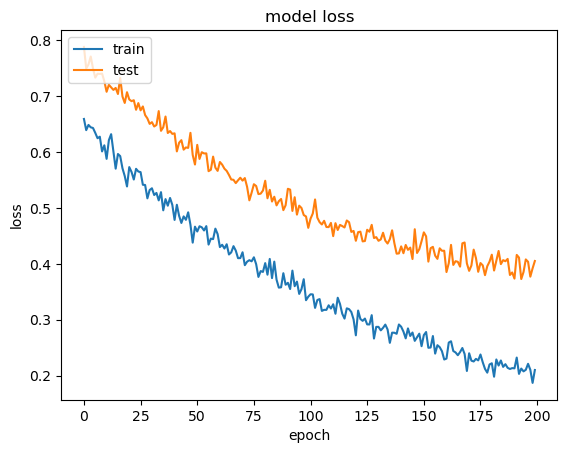

In [23]:
plt.plot(cnnhistory.history['loss'])
plt.plot(cnnhistory.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

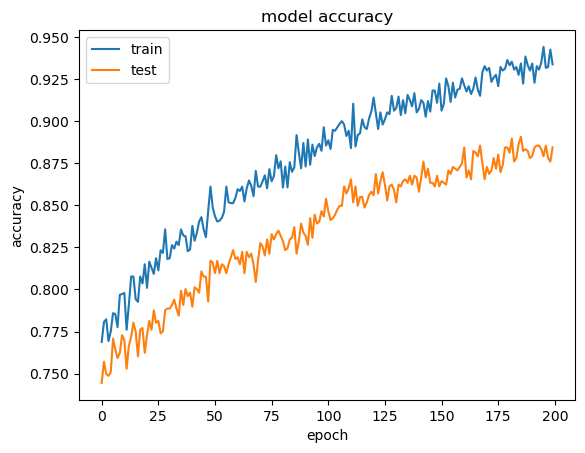

In [24]:
plt.plot(cnnhistory.history['accuracy'])
plt.plot(cnnhistory.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [26]:
import numpy as np

predictions = model.predict(x_testcnn)
predicted_classes = np.argmax(predictions, axis=1)

# predictions = model.predict_classes(x_testcnn)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [28]:
predicted_classes

array([6, 6, 0, 0, 5, 3, 2, 6, 3, 1, 3, 3, 1, 6, 3, 7, 5, 7, 4, 1, 2, 2,
       7, 6, 7, 1, 1, 1, 2, 1, 3, 3, 4, 6, 3, 1, 7, 7, 4, 4, 4, 7, 1, 4,
       5, 6, 1, 6, 1, 1, 7, 4, 3, 0, 6, 2, 3, 7, 4, 5, 2, 1, 2, 3, 6, 1,
       5, 5, 7, 6, 4, 7, 5, 7, 7, 1, 5, 1, 5, 3, 4, 4, 1, 0, 4, 3, 2, 2,
       4, 2, 1, 1, 6, 7, 7, 7, 6, 7, 0, 1, 7, 4, 7, 1, 3, 5, 4, 6, 4, 4,
       2, 5, 7, 2, 5, 7, 7, 3, 5, 7, 0, 2, 2, 2, 7, 0, 6, 3, 6, 2, 7, 1,
       2, 3, 4, 5, 3, 5, 3, 7, 2, 2, 0, 2, 2, 7, 4, 4, 3, 4, 4, 2, 3, 2,
       2, 2, 0, 3, 1, 6, 3, 5, 6, 4, 6, 3, 6, 4, 7, 7, 7, 6, 2, 0, 5, 6,
       1, 2, 3, 1, 2, 1, 3, 2, 6, 5, 0, 0, 2, 5, 7, 6, 4, 6, 6, 5, 2, 4,
       1, 3, 4, 3, 1, 1, 3, 5, 4, 1, 3, 6, 0, 7, 3, 6, 7, 2, 7, 3, 4, 5,
       6, 5, 7, 5, 5, 2, 5, 1, 6, 0, 0, 7, 5, 6, 3, 4, 5, 6, 5, 7, 4, 2,
       4, 4, 7, 2, 7, 4, 3, 2, 6, 3, 7, 4, 6, 5, 3, 3, 2, 4, 7, 7, 1, 3,
       3, 3, 7, 4, 7, 6, 7, 5, 3, 5, 3, 4, 1, 3, 5, 4, 3, 1, 7, 4, 0, 4,
       6, 0, 6, 6, 1, 6, 4, 5, 2, 1, 7, 7, 3, 2, 5,

In [29]:
y_test

array([6, 6, 3, 1, 5, 3, 2, 6, 3, 1, 3, 3, 1, 3, 3, 7, 5, 7, 4, 1, 2, 2,
       7, 6, 7, 1, 1, 1, 2, 1, 3, 3, 4, 6, 0, 1, 7, 7, 4, 4, 4, 2, 1, 4,
       5, 6, 1, 6, 1, 1, 0, 6, 3, 0, 6, 2, 3, 7, 4, 5, 2, 1, 2, 5, 6, 1,
       5, 5, 7, 1, 4, 7, 5, 7, 7, 1, 5, 1, 5, 3, 4, 4, 1, 0, 4, 3, 2, 2,
       4, 2, 1, 1, 6, 7, 7, 7, 6, 7, 0, 1, 7, 4, 7, 1, 3, 5, 4, 6, 4, 4,
       2, 5, 7, 2, 5, 7, 7, 3, 5, 0, 0, 2, 2, 2, 7, 0, 6, 3, 6, 2, 4, 1,
       2, 3, 4, 5, 3, 5, 3, 7, 0, 2, 1, 2, 2, 7, 4, 4, 2, 4, 4, 2, 3, 2,
       2, 2, 1, 5, 1, 6, 3, 5, 6, 4, 6, 3, 3, 6, 7, 7, 7, 6, 2, 0, 5, 6,
       1, 2, 3, 1, 2, 1, 3, 2, 6, 5, 0, 0, 2, 5, 7, 6, 4, 6, 6, 5, 2, 6,
       1, 2, 4, 3, 1, 1, 3, 5, 4, 0, 3, 6, 3, 7, 3, 6, 7, 2, 7, 3, 4, 5,
       6, 5, 7, 5, 5, 2, 5, 1, 6, 0, 1, 7, 5, 6, 3, 4, 5, 6, 5, 7, 3, 2,
       6, 4, 7, 2, 7, 4, 3, 2, 6, 3, 4, 4, 6, 5, 0, 3, 2, 4, 7, 7, 1, 3,
       3, 6, 7, 4, 7, 6, 7, 5, 3, 5, 3, 4, 1, 3, 5, 4, 3, 1, 7, 4, 0, 4,
       4, 0, 6, 4, 1, 6, 4, 5, 2, 1, 7, 7, 3, 2, 5,

In [30]:
new_Ytest = y_test.astype(int)

In [31]:
new_Ytest

array([6, 6, 3, 1, 5, 3, 2, 6, 3, 1, 3, 3, 1, 3, 3, 7, 5, 7, 4, 1, 2, 2,
       7, 6, 7, 1, 1, 1, 2, 1, 3, 3, 4, 6, 0, 1, 7, 7, 4, 4, 4, 2, 1, 4,
       5, 6, 1, 6, 1, 1, 0, 6, 3, 0, 6, 2, 3, 7, 4, 5, 2, 1, 2, 5, 6, 1,
       5, 5, 7, 1, 4, 7, 5, 7, 7, 1, 5, 1, 5, 3, 4, 4, 1, 0, 4, 3, 2, 2,
       4, 2, 1, 1, 6, 7, 7, 7, 6, 7, 0, 1, 7, 4, 7, 1, 3, 5, 4, 6, 4, 4,
       2, 5, 7, 2, 5, 7, 7, 3, 5, 0, 0, 2, 2, 2, 7, 0, 6, 3, 6, 2, 4, 1,
       2, 3, 4, 5, 3, 5, 3, 7, 0, 2, 1, 2, 2, 7, 4, 4, 2, 4, 4, 2, 3, 2,
       2, 2, 1, 5, 1, 6, 3, 5, 6, 4, 6, 3, 3, 6, 7, 7, 7, 6, 2, 0, 5, 6,
       1, 2, 3, 1, 2, 1, 3, 2, 6, 5, 0, 0, 2, 5, 7, 6, 4, 6, 6, 5, 2, 6,
       1, 2, 4, 3, 1, 1, 3, 5, 4, 0, 3, 6, 3, 7, 3, 6, 7, 2, 7, 3, 4, 5,
       6, 5, 7, 5, 5, 2, 5, 1, 6, 0, 1, 7, 5, 6, 3, 4, 5, 6, 5, 7, 3, 2,
       6, 4, 7, 2, 7, 4, 3, 2, 6, 3, 4, 4, 6, 5, 0, 3, 2, 4, 7, 7, 1, 3,
       3, 6, 7, 4, 7, 6, 7, 5, 3, 5, 3, 4, 1, 3, 5, 4, 3, 1, 7, 4, 0, 4,
       4, 0, 6, 4, 1, 6, 4, 5, 2, 1, 7, 7, 3, 2, 5,

In [34]:
from sklearn.metrics import classification_report

report = classification_report(new_Ytest, predicted_classes)
print(report)


# from sklearn.metrics import classification_report
# report = classification_report(new_Ytest, predictions)
# print(report)

              precision    recall  f1-score   support

           0       0.65      0.66      0.65        61
           1       0.94      0.82      0.88       147
           2       0.98      0.85      0.91       132
           3       0.86      0.87      0.86       134
           4       0.90      0.94      0.92       120
           5       0.93      0.95      0.94       105
           6       0.84      0.89      0.87       123
           7       0.88      1.00      0.93       129

    accuracy                           0.88       951
   macro avg       0.87      0.87      0.87       951
weighted avg       0.89      0.88      0.88       951



In [35]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(new_Ytest, predicted_classes)
print (matrix)

# 0 = neutral, 1 = calm, 2 = happy, 3 = sad, 4 = angry, 5 = fearful, 6 = disgust, 7 = surprised

[[ 40   7   2   6   0   0   2   4]
 [ 16 121   0   2   0   0   6   2]
 [  2   0 112   4   2   4   0   8]
 [  4   1   0 116   1   2   8   2]
 [  0   0   0   0 113   0   5   2]
 [  0   0   0   5   0 100   0   0]
 [  0   0   0   2   9   2 110   0]
 [  0   0   0   0   0   0   0 129]]


In [36]:
model.save('testing-16-200_model.h5')
print("MODEL SAVED")

MODEL SAVED


In [38]:
from tensorflow import keras
new_model=keras.models.load_model('testing-16-200_model.h5')
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 256)         │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         4,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,674 (819.04 KB)

 Trainable params: 209,672 (819.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [39]:
loss, acc = new_model.evaluate(x_testcnn, y_test)
print("Restored model, accuracy: {:5.2f}%".format(100*acc))

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.8977 - loss: 0.3623
Restored model, accuracy: 88.43%
